# Financial Analysis Notebook
This notebook loads the consolidated financials produced by `financial_data_collector.py`, computes a simple revenue growth metric, and plots the results.  
It uses relative paths so that it works regardless of the user’s local directory.


Year                 Year   Revenue  Net_Income  Total_Assets  Total_Debt  \
0     2021-12-31 00:00:00       NaN         NaN           NaN         NaN   
1     2022-12-31 00:00:00  234121.0    -22759.0      948465.0    120315.0   
2     2023-12-31 00:00:00  439337.0     96223.0     1069978.0    122936.0   
3     2024-12-31 00:00:00  424232.0     88995.0     1153881.0    122324.0   
4     2025-12-31 00:00:00  410522.0     66968.0     1222176.0    125763.0   

Year  Revenue_Growth  
0                NaN  
1                NaN  
2           0.876538  
3          -0.034381  
4          -0.032317  


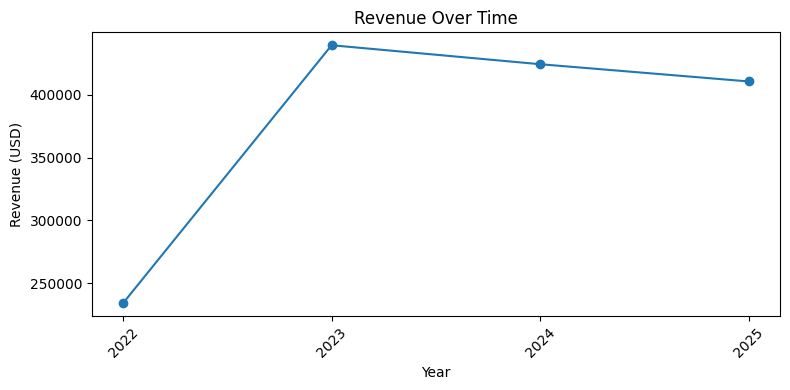

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# locate the data file by searching upward from current working directory
cwd = Path().resolve()
data_file = None
for ancestor in [cwd] + list(cwd.parents):
    candidate = ancestor / "data" / "company_financials.csv"
    if candidate.exists():
        data_file = candidate
        break

if data_file is None:
    raise FileNotFoundError("Could not find data/company_financials.csv in any parent directory")

# read raw CSV
raw = pd.read_csv(data_file)

# the file is stored transposed due to earlier DataFrame orientation;
# rows are metrics and columns are years, with the first column labeled 'Year'.
# pivot it so years become rows and metrics become columns.
if 'Year' in raw.columns and raw.columns[0] == 'Year':
    data = raw.set_index('Year').transpose()
    data.index.name = 'Year'
    data = data.reset_index()
else:
    data = raw.copy()

# ensure required columns are present after pivot
required = ["Year", "Revenue"]
missing = [c for c in required if c not in data.columns]
if missing:
    raise KeyError(f"Missing columns in data file: {missing}")

# compute derived metrics
if "Revenue_Growth" not in data.columns:
    data["Revenue_Growth"] = data["Revenue"].pct_change()

print(data)

# convert Year to string for plotting if it's a datetime or period
try:
    data["Year"] = pd.to_datetime(data["Year"]).dt.year.astype(str)
except Exception:
    pass

plt.figure(figsize=(8,4))
plt.plot(data["Year"], data["Revenue"], marker="o")
plt.title("Revenue Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()

# use the same base as data_file for output
output_dir = data_file.parent.parent / "visuals"
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / "revenue_growth.png")
plt.show()
